In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import os
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import multilabel_confusion_matrix
from statistics import mean
import math
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import matthews_corrcoef
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

In [ ]:
!nvidia-smi


Sat Sep 20 18:47:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Read CSV into dataframe
df = pd.read_csv('/content/drive/MyDrive/Data Folder_TE/Final FV/COMBINE FILE-FV/DATASET 3.csv')

# Separate labels (target column)
labels = df['label']

# Drop the label column from features
feature = df.drop(columns=['label'])

# Check shapes
print("Features shape:", feature.shape)
print("Labels shape:", labels.shape)


Features shape: (98041, 521)
Labels shape: (98041,)


**Label Encoder**

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
feature = feature.apply(le.fit_transform)

In [ ]:
labels.shape


(98041,)

In [ ]:
import seaborn as sns
countplt, ax = plt.subplots(figsize = (10,7))
ax = sns.countplot(labels ,palette="Set2")

/tmp/ipython-input-1470246520.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(labels ,palette="Set2")


KeyboardInterrupt: 

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Error in callback <function _draw_all_if_interactive at 0x7a9aa011b1a0> (for post_execute):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/events.py", line 89, in trigger
    func(*args, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py", line 279, in _draw_all_if_interactive
    draw_all()
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/_pylab_helpers.py", line 131, in draw_all
    manager.canvas.draw_idle()
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/backend_bases.py", line 1891, in draw_idle
    self.draw(*args, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/backends/backend_agg.py", line 382, in draw
    self.figure.draw(self.renderer)
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/artist.py", line 94, in draw_wrapper
    result = draw(artist, renderer, *args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/p

**Standard Scaler For Features Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.get_params()
feature=scaler.fit_transform(feature)

In [ ]:
print(np.any(np.isinf(feature)))
print(np.any(np.isinf(labels)))


False
False


# **SELF CONSISTENCY TEST**

Self-Consistency Accuracy: 97.19%

Confusion Matrix:
 [[47073  1968]
 [  785 48215]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97     49041
           1       0.96      0.98      0.97     49000

    accuracy                           0.97     98041
   macro avg       0.97      0.97      0.97     98041
weighted avg       0.97      0.97      0.97     98041


MCC ---> 0.9441


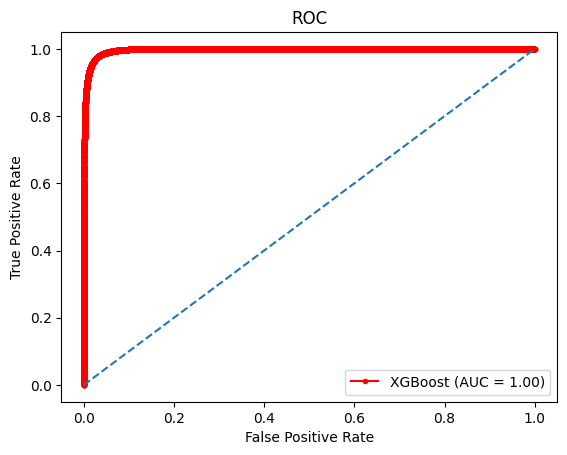

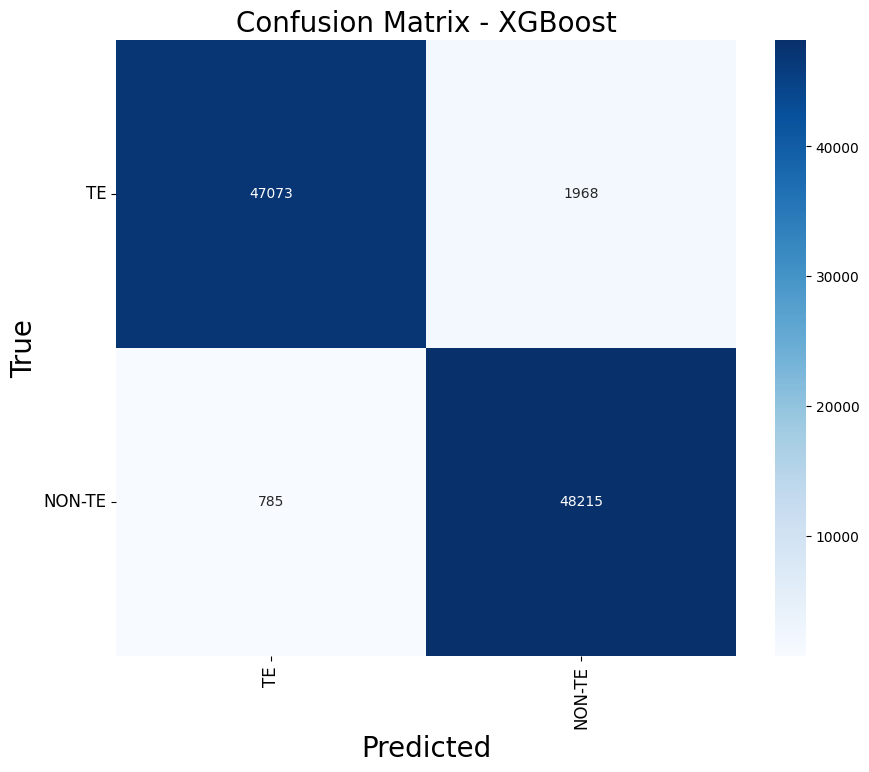

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef

# ==============================
# Define optimized model
# ==============================
xgb_model = XGBClassifier(n_estimators=100)

# ==============================
# Train on ALL data (self-consistency)
# ==============================
xgb_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = xgb_model.predict(feature)
pred_prob = xgb_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_xgb = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_xgb)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_xg = {}
tpr_xg = {}
thresh_xg ={}

n_class = 2

for i in range(n_class):
    fpr_xg[i], tpr_xg[i], thresh_xg[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_xg = auc(fpr_xg[i], tpr_xg[i])
roc_xg
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_xg[i], tpr_xg[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xg)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-xgb_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['TE','NON-TE']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

# Save & show
plt.savefig('xgb_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 97.19%

Confusion Matrix:
 [[47073  1968]
 [  785 48215]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97     49041
           1       0.96      0.98      0.97     49000

    accuracy                           0.97     98041
   macro avg       0.97      0.97      0.97     98041
weighted avg       0.97      0.97      0.97     98041


MCC ---> 0.9441


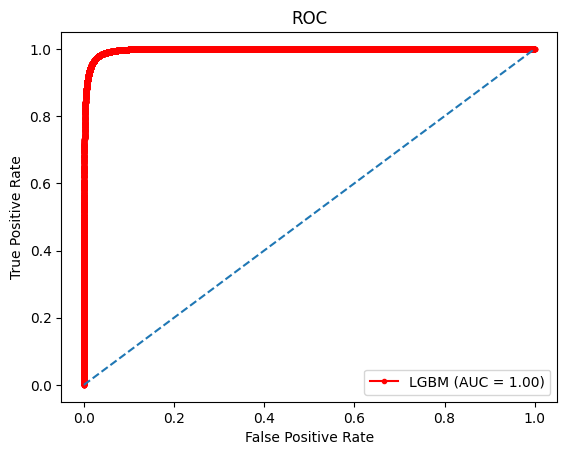

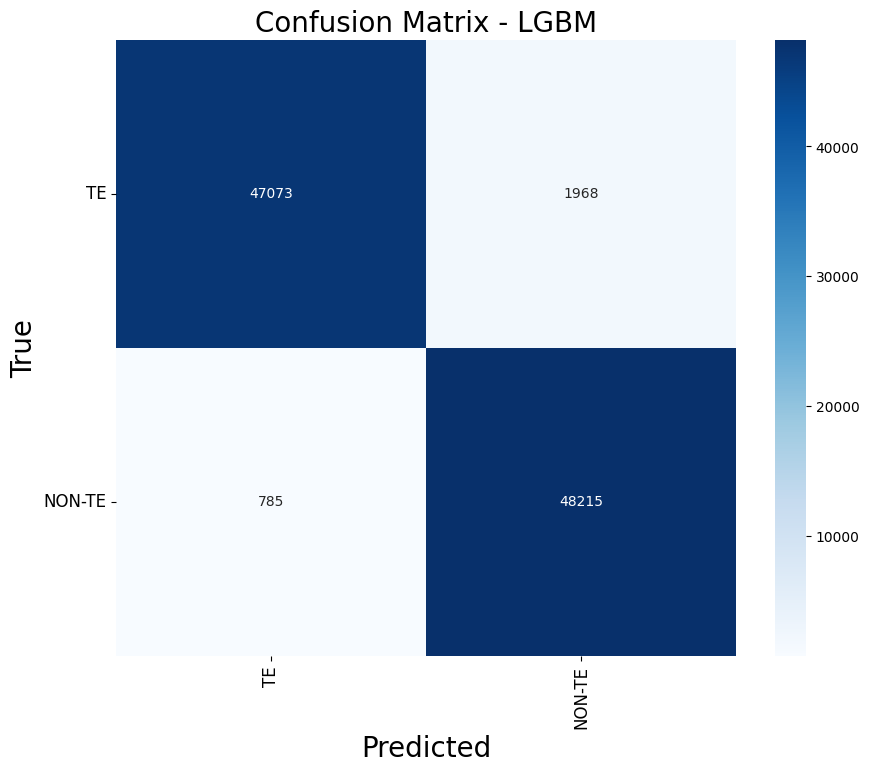

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef, roc_curve, auc
from lightgbm import LGBMClassifier

# ==============================
# Define optimized LightGBM model
# ==============================
lgbm_model = LGBMClassifier(
    n_estimators=100
)

import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef

# ==============================
# Define optimized model
# ==============================
lgbm_model = XGBClassifier(n_estimators=100)

# ==============================
# Train on ALL data (self-consistency)
# ==============================
lgbm_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = lgbm_model.predict(feature)
pred_prob = lgbm_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_lgbm = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_lgbm)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_lgbm = {}
tpr_lgbm = {}
thresh_lgbm ={}


n_class = 2

for i in range(n_class):
    fpr_lgbm[i], tpr_lgbm[i], thresh_lgbm[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_lgbm = auc(fpr_lgbm[i], tpr_lgbm[i])
roc_lgbm
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_lgbm[i], tpr_lgbm[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-lgbm_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['TE','NON-TE']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

# Save & show
plt.savefig('lgbm_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 99.37%

Confusion Matrix:
 [[48790   251]
 [  365 48635]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     49041
           1       0.99      0.99      0.99     49000

    accuracy                           0.99     98041
   macro avg       0.99      0.99      0.99     98041
weighted avg       0.99      0.99      0.99     98041


MCC ---> 0.9874


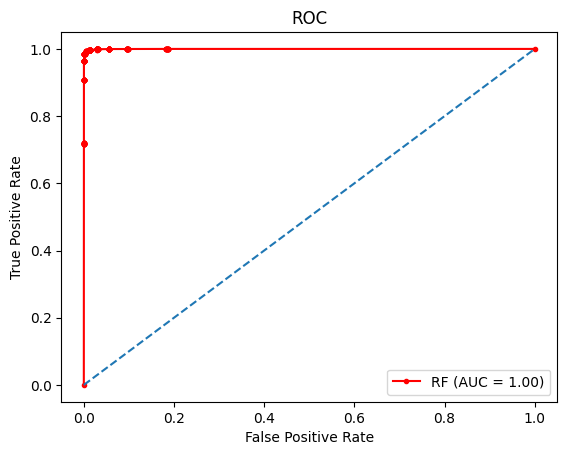

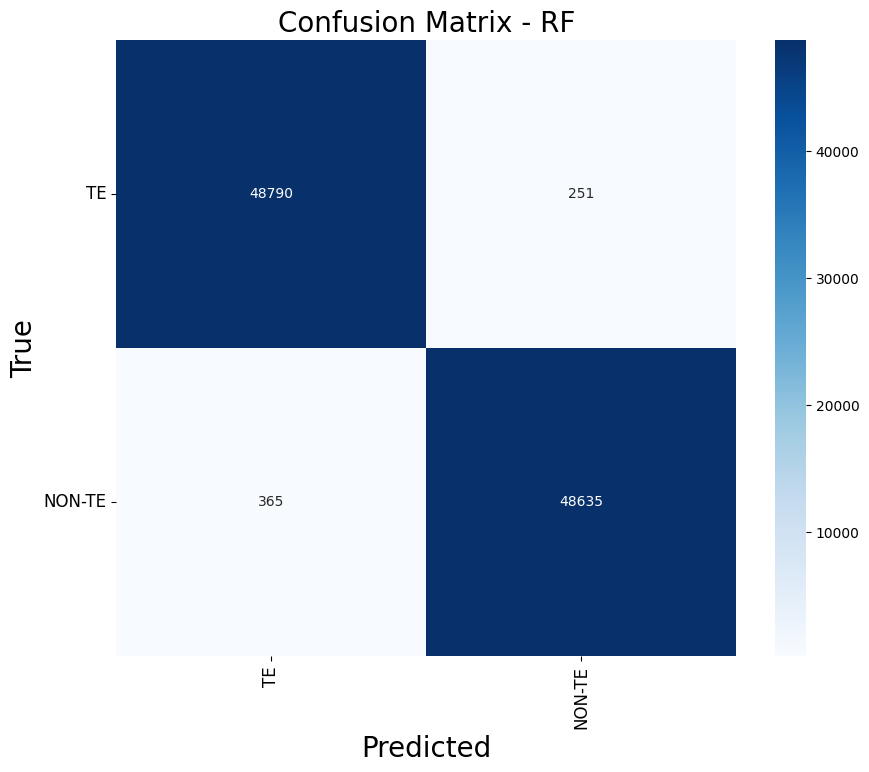

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    matthews_corrcoef, roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# ==============================
# Define Random Forest model
# ==============================
rf_model = RandomForestClassifier(n_estimators=10, random_state=10)
# ==============================
# Train on ALL data (self-consistency)
# ==============================
rf_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = rf_model.predict(feature)
pred_prob = rf_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_rf = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_rf)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_rf = {}
tpr_rf = {}
thresh_rf ={}


n_class = 2

for i in range(n_class):
    fpr_rf[i], tpr_rf[i], thresh_rf[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_rf = auc(fpr_rf[i], tpr_rf[i])
roc_rf
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_rf[i], tpr_rf[i], marker='.', color='red',
         label='RF (AUC = %0.2f)' % roc_rf)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-rf_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['TE','NON-TE']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - RF', fontsize=20)

# Save & show
plt.savefig('rf_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 99.75%

Confusion Matrix:
 [[49025    16]
 [  227 48773]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     49041
           1       1.00      1.00      1.00     49000

    accuracy                           1.00     98041
   macro avg       1.00      1.00      1.00     98041
weighted avg       1.00      1.00      1.00     98041


MCC ---> 0.9951


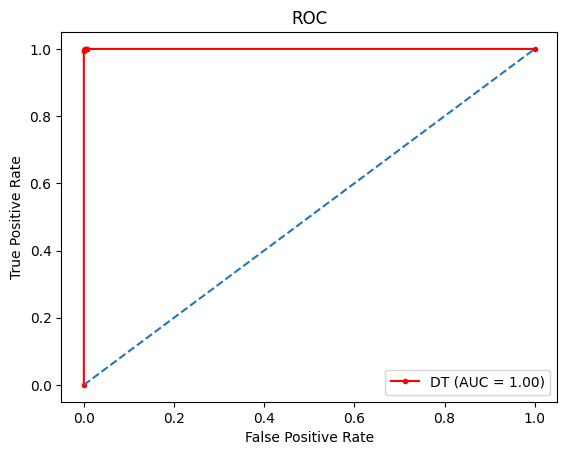

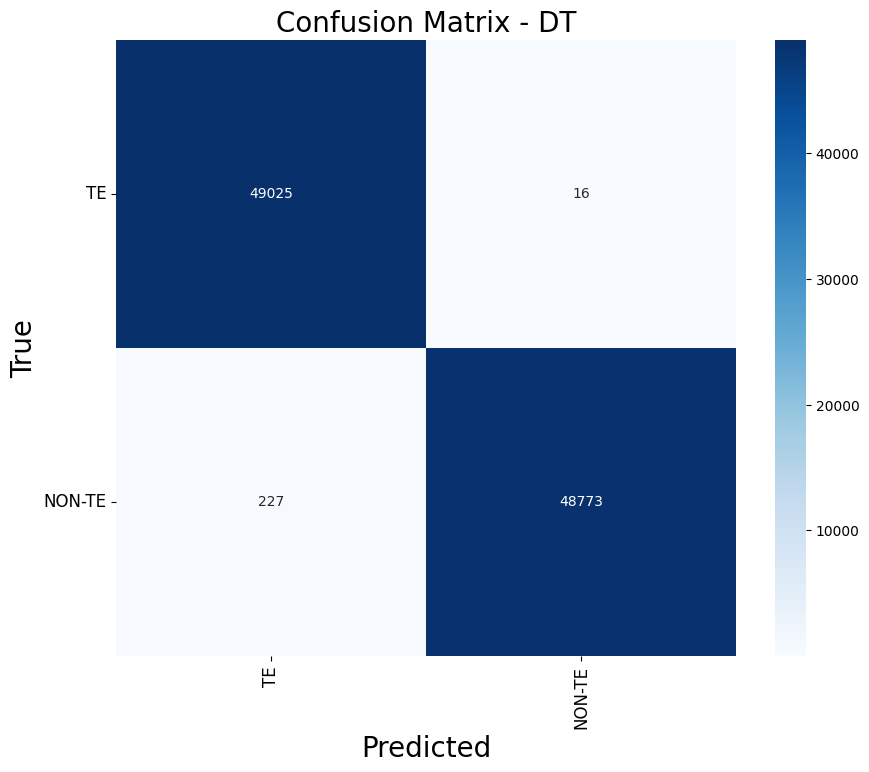

In [ ]:
 dt_model = DecisionTreeClassifier()
# train the model using X_train_dtm & y_train

# ==============================
# Train on ALL data (self-consistency)
# ==============================
dt_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = dt_model.predict(feature)
pred_prob = dt_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_dt = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_dt)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_dt = {}
tpr_dt = {}
thresh_dt ={}


n_class = 2

for i in range(n_class):
    fpr_dt[i], tpr_dt[i], thresh_dt[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_dt = auc(fpr_dt[i], tpr_dt[i])
roc_dt
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_dt[i], tpr_dt[i], marker='.', color='red',
         label='DT (AUC = %0.2f)' % roc_dt)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-dt_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['TE','NON-TE']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - DT', fontsize=20)

# Save & show
plt.savefig('dt_self-test_cm.png')
plt.show()


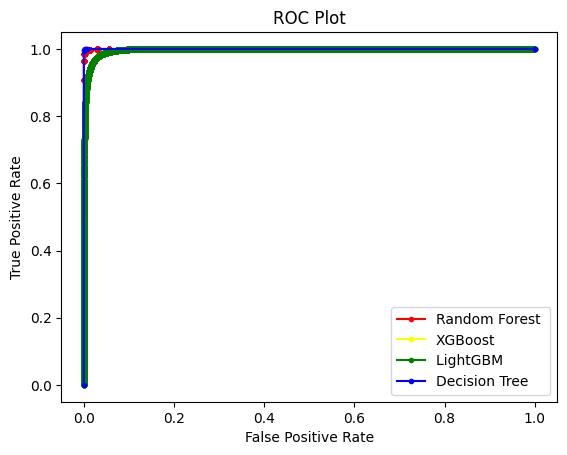

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rf[i],tpr_rf[i], marker='.',color='red',label = 'Random Forest ' % roc_rf)
plt.plot(fpr_xg[i],tpr_xg[i], marker='.',color='yellow',label = 'XGBoost' % roc_xg)
plt.plot(fpr_lgbm[i],tpr_lgbm[i], marker='.',color='green',label = 'LightGBM ' % roc_lgbm)
plt.plot(fpr_dt[i],tpr_dt[i], marker='.',color='blue',label = 'Decision Tree' % roc_dt)
plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #
plt.savefig('self-test_roc.png')
# Show plot
plt.show()


**INDEPENDENT TESTING**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(feature, labels, test_size=0.3, random_state=100,stratify=labels)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(68628, 521) (29413, 521)
(68628,) (29413,)


Training accuracy is 0.9786967418546366
Test accuracy is 0.9368646516846293
[[13547  1166]
 [  691 14009]]
              precision    recall  f1-score   support

           0       0.95      0.92      0.94     14713
           1       0.92      0.95      0.94     14700

    accuracy                           0.94     29413
   macro avg       0.94      0.94      0.94     29413
weighted avg       0.94      0.94      0.94     29413

Accuracy 93.69%
MCC ---> 0.8741871644372363
Sensitivity :  0.9207503568272956
Specificity :  0.9529931972789115


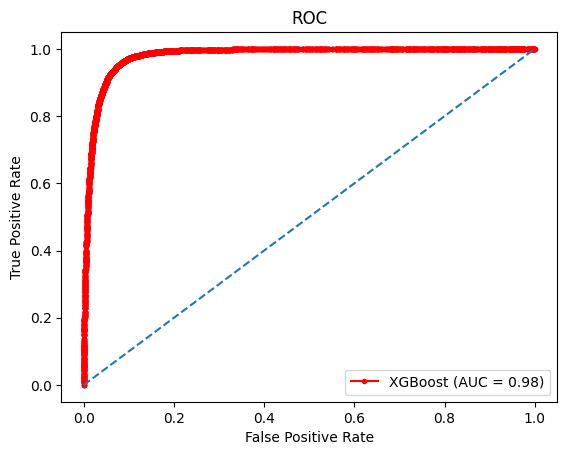

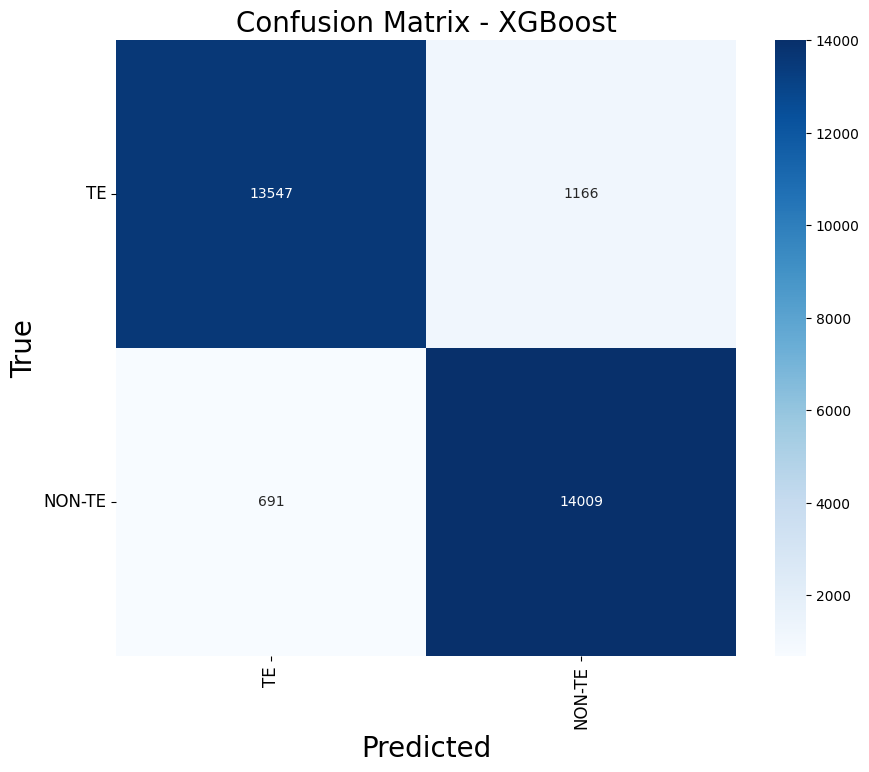

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef
xgb1 = XGBClassifier(n_estimators=100)
xgb1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = xgb1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = xgb1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = xgb1.predict_proba(X_test)

cm_xgb1 = confusion_matrix(y_test, y_pred_test)
print(cm_xgb1)

cr_xgb1 = classification_report(y_test, y_pred_test)
print(cr_xgb1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_xgb1[0,0] / (cm_xgb1[0,0] + cm_xgb1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_xgb1[1,1] / (cm_xgb1[1,0] + cm_xgb1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_xgb1 = {}
tpr_xgb1 = {}
thresh_xgb1 = {}

n_class = 2

for i in range(n_class):
    fpr_xgb1[i], tpr_xgb1[i], thresh_xgb1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_xgb1 = auc(fpr_xgb1[i], tpr_xgb1[i])

roc_xgb1
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_xgb1[i], tpr_xgb1[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xgb1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-xgb1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred_test)

## Get Class Labels
labels = ['TE','NON-TE']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

# Save & show
plt.savefig('xgb1_indep-test_cm.png')
plt.show()


Training accuracy is 0.9942589030716326
Test accuracy is 0.9274130486519566
[[13549  1164]
 [  971 13729]]
              precision    recall  f1-score   support

           0       0.93      0.92      0.93     14713
           1       0.92      0.93      0.93     14700

    accuracy                           0.93     29413
   macro avg       0.93      0.93      0.93     29413
weighted avg       0.93      0.93      0.93     29413

Accuracy 92.74%
MCC ---> 0.8549005309228248
Sensitivity :  0.920886291035139
Specificity :  0.9339455782312925


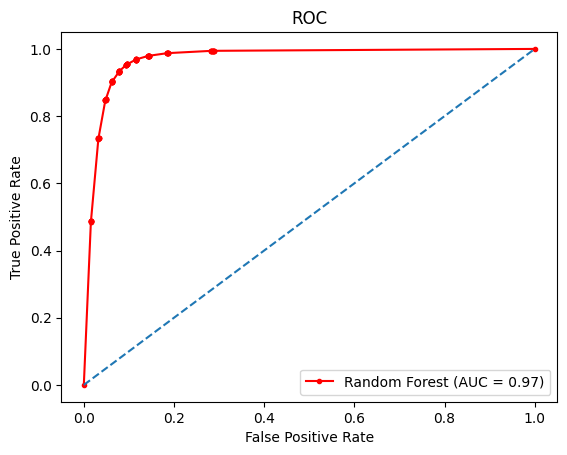

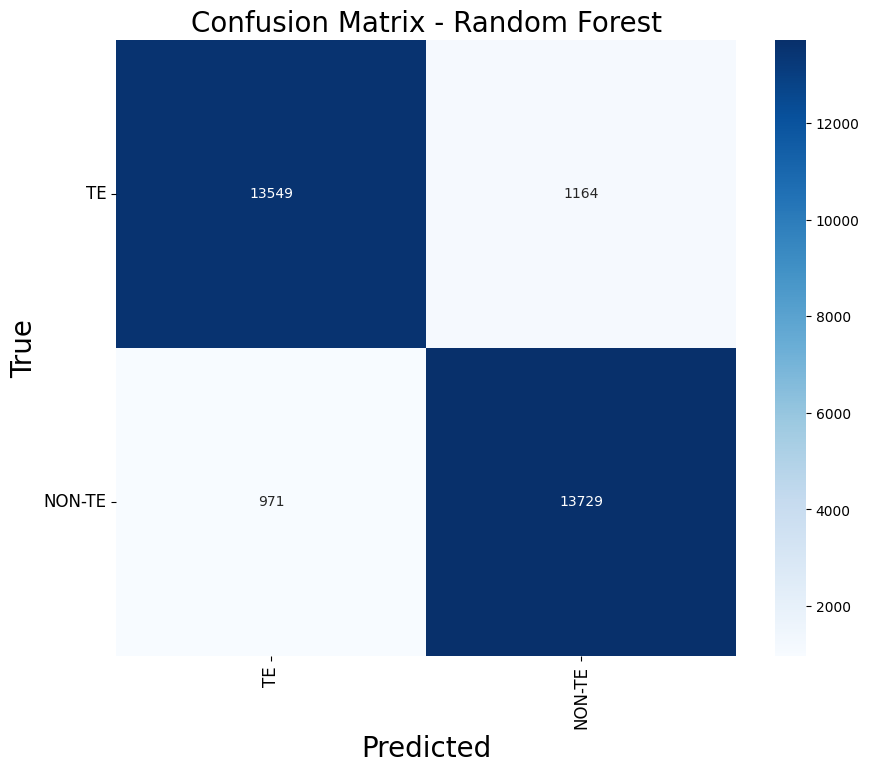

In [ ]:
rclf1 = RandomForestClassifier(n_estimators=10,random_state=10)
rclf1.fit(X_train, y_train)
rclf1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = rclf1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = rclf1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = rclf1.predict_proba(X_test)

cm_rclf1 = confusion_matrix(y_test, y_pred_test)
print(cm_rclf1)

cr_rclf1 = classification_report(y_test, y_pred_test)
print(cr_rclf1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_rclf1[0,0] / (cm_rclf1[0,0] + cm_rclf1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_rclf1[1,1] / (cm_rclf1[1,0] + cm_rclf1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_rclf1 = {}
tpr_rclf1 = {}
thresh_rclf1 = {}

n_class = 2

for i in range(n_class):
    fpr_rclf1[i], tpr_rclf1[i], thresh_rclf1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_rclf1 = auc(fpr_rclf1[i], tpr_rclf1[i])

roc_rclf1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_rclf1[i], tpr_rclf1[i], marker='.', color='red',
         label='Random Forest (AUC = %0.2f)' % roc_rclf1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-rclf1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['TE','NON-TE']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Random Forest', fontsize=20)

# Save & show
plt.savefig('rclf1_indep-test_cm.png')
plt.show()


Training accuracy is 0.998062015503876
Test accuracy is 0.8967123380818006
[[13290  1423]
 [ 1615 13085]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     14713
           1       0.90      0.89      0.90     14700

    accuracy                           0.90     29413
   macro avg       0.90      0.90      0.90     29413
weighted avg       0.90      0.90      0.90     29413

Accuracy 89.67%
MCC ---> 0.7934910707167799
Sensitivity :  0.9032828111194182
Specificity :  0.8901360544217687


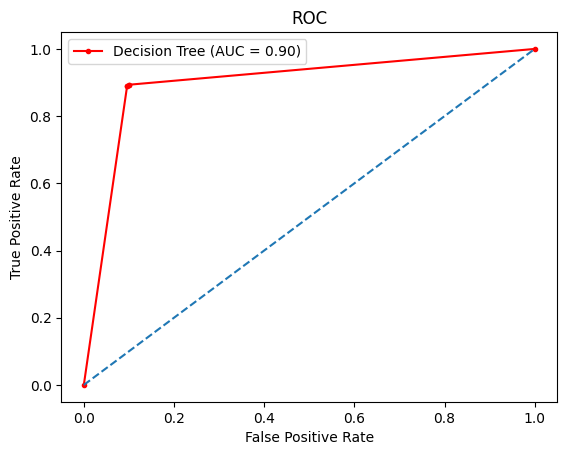

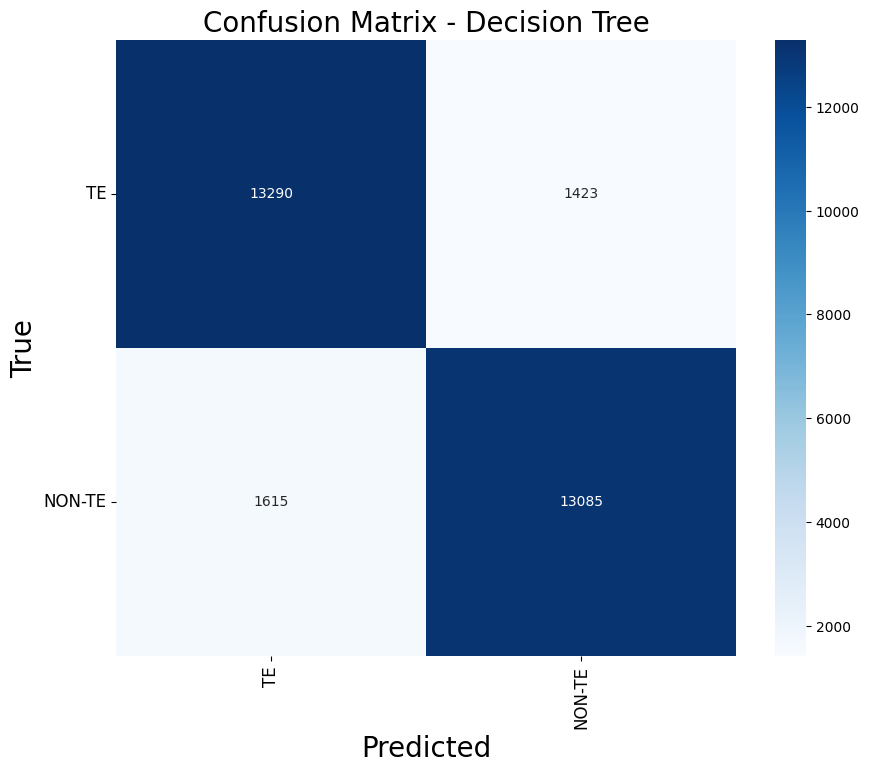

In [ ]:
dt1 = DecisionTreeClassifier()
dt1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = dt1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = dt1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = dt1.predict_proba(X_test)

cm_dt1 = confusion_matrix(y_test, y_pred_test)
print(cm_dt1)

cr_dt1 = classification_report(y_test, y_pred_test)
print(cr_dt1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_dt1[0,0] / (cm_dt1[0,0] + cm_dt1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_dt1[1,1] / (cm_dt1[1,0] + cm_dt1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_dt1 = {}
tpr_dt1 = {}
thresh_dt1 = {}

n_class = 2

for i in range(n_class):
    fpr_dt1[i], tpr_dt1[i], thresh_dt1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_dt1 = auc(fpr_dt1[i], tpr_dt1[i])

roc_dt1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_dt1[i], tpr_dt1[i], marker='.', color='red',
         label='Decision Tree (AUC = %0.2f)' % roc_dt1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-dt1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['TE','NON-TE']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Decision Tree', fontsize=20)

# Save & show
plt.savefig('dt1_indep-test_cm.png')
plt.show()



[LightGBM] [Info] Number of positive: 34300, number of negative: 34328
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.982116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127478
[LightGBM] [Info] Number of data points in the train set: 68628, number of used features: 516
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499796 -> initscore=-0.000816
[LightGBM] [Info] Start training from score -0.000816


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training accuracy is 0.94812612927668


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test accuracy is 0.9325468330330127


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[[13452  1261]
 [  723 13977]]
              precision    recall  f1-score   support

           0       0.95      0.91      0.93     14713
           1       0.92      0.95      0.93     14700

    accuracy                           0.93     29413
   macro avg       0.93      0.93      0.93     29413
weighted avg       0.93      0.93      0.93     29413

Accuracy 93.25%
MCC ---> 0.8656752528448721
Sensitivity :  0.9142934819547339
Specificity :  0.9508163265306122


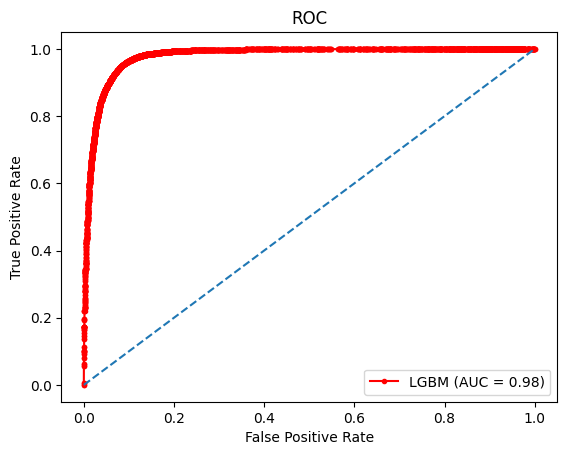

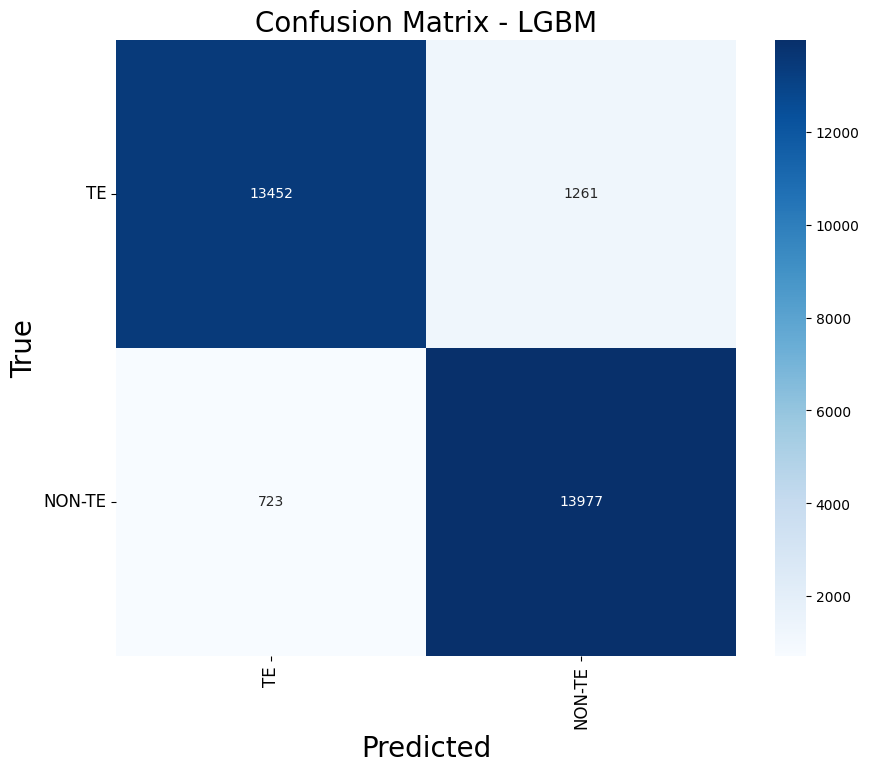

In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

lgbm1 = LGBMClassifier(
    n_estimators=100
)

lgbm1.fit(X_train, y_train)

# compute the training accuracy
y_pred_train = lgbm1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = lgbm1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = lgbm1.predict_proba(X_test)

cm_lgbm1 = confusion_matrix(y_test, y_pred_test)
print(cm_lgbm1)

cr_lgbm1 = classification_report(y_test, y_pred_test)
print(cr_lgbm1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_lgbm1[0,0] / (cm_lgbm1[0,0] + cm_lgbm1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_lgbm1[1,1] / (cm_lgbm1[1,0] + cm_lgbm1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_lgbm1 = {}
tpr_lgbm1 = {}
thresh_lgbm1 = {}

n_class = 2

for i in range(n_class):
    fpr_lgbm1[i], tpr_lgbm1[i], thresh_lgbm1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_lgbm1 = auc(fpr_lgbm1[i], tpr_lgbm1[i])

roc_lgbm1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_lgbm1[i], tpr_lgbm1[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-lgbm1_roc.png')
# Show plot
plt.show()


### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['TE','NON-TE']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

# Save & show
plt.savefig('lgbm1_indep-test_cm.png')
plt.show()


**ROC-INDEPENDENT TEST**

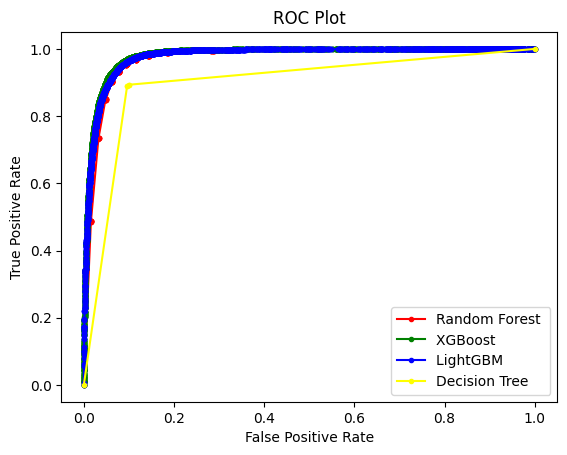

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rclf1[i],tpr_rclf1[i], marker='.',color='red',label = 'Random Forest ' % roc_rclf1)
plt.plot(fpr_xgb1[i],tpr_xgb1[i], marker='.',color='green',label = 'XGBoost ' % roc_xgb1)
plt.plot(fpr_lgbm1[i],tpr_lgbm1[i], marker='.',color='blue',label = 'LightGBM ' % roc_lgbm1)
plt.plot(fpr_dt1[i],tpr_dt1[i], marker='.',color='yellow',label = 'Decision Tree ' % roc_dt1)
plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #
plt.savefig('INDE-test_roc.png')
# Show plot
plt.show()


# **Cross Validation Test**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score,matthews_corrcoef

Random Forest – 10-Fold Cross-Validation (Mean ± Std)

Accuracy    : 0.933 ± 0.002
MCC         : 0.866 ± 0.005
Sensitivity : 0.942 ± 0.003
Specificity : 0.924 ± 0.004
AUC         : 0.972 ± 0.002


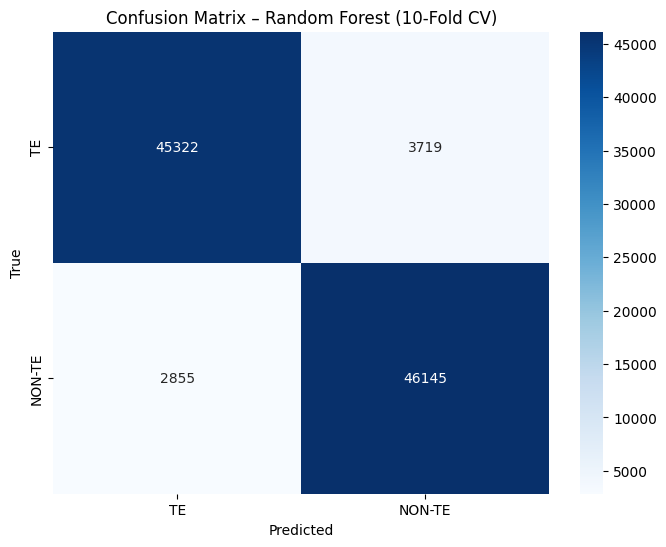

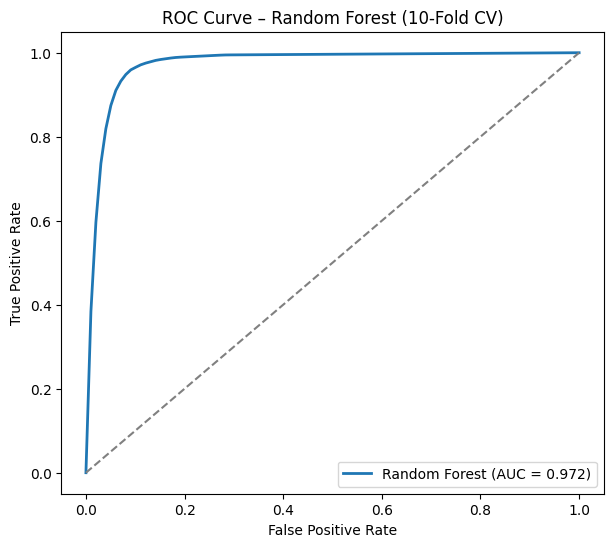

In [ ]:
# ===================== Imports =====================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.ensemble import RandomForestClassifier

# ===================== Cross-validation setup =====================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ===================== Storage (for metrics & ROC) =====================
rf_acc_scores = []
rf_mcc_scores = []
rf_sen_scores = []
rf_spe_scores = []
rf_auc_scores = []

rf_fpr_list = []
rf_tpr_list = []

y_true_all_rf = []
y_pred_all_rf = []

# ===================== Cross-validation loop =====================
for fold, (train_idx, test_idx) in enumerate(skf.split(feature, labels), 1):
    X_train, X_test = feature[train_idx], feature[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    model_rf = RandomForestClassifier(
        n_estimators=10,
        random_state=10
    )

    model_rf.fit(X_train, y_train)

    # Predictions
    y_pred_rf = model_rf.predict(X_test)
    y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

    # Store global predictions
    y_true_all_rf.extend(y_test)
    y_pred_all_rf.extend(y_pred_rf)

    # ---------------- Metrics ----------------
    acc = accuracy_score(y_test, y_pred_rf)
    mcc = matthews_corrcoef(y_test, y_pred_rf)

    cm = confusion_matrix(y_test, y_pred_rf)
    TP = cm[1,1]
    TN = cm[0,0]
    FP = cm[0,1]
    FN = cm[1,0]

    sensitivity = TP / (TP + FN)  # Recall for positive class
    specificity = TN / (TN + FP)

    fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
    roc_auc = auc(fpr, tpr)

    # Store fold-wise results
    rf_acc_scores.append(acc)
    rf_mcc_scores.append(mcc)
    rf_sen_scores.append(sensitivity)
    rf_spe_scores.append(specificity)
    rf_auc_scores.append(roc_auc)

    rf_fpr_list.append(fpr)
    rf_tpr_list.append(tpr)

# ===================== Statistical Summary =====================
print("Random Forest – 10-Fold Cross-Validation (Mean ± Std)\n")
print(f"Accuracy    : {np.mean(rf_acc_scores):.3f} ± {np.std(rf_acc_scores, ddof=1):.3f}")
print(f"MCC         : {np.mean(rf_mcc_scores):.3f} ± {np.std(rf_mcc_scores, ddof=1):.3f}")
print(f"Sensitivity : {np.mean(rf_sen_scores):.3f} ± {np.std(rf_sen_scores, ddof=1):.3f}")
print(f"Specificity : {np.mean(rf_spe_scores):.3f} ± {np.std(rf_spe_scores, ddof=1):.3f}")
print(f"AUC         : {np.mean(rf_auc_scores):.3f} ± {np.std(rf_auc_scores, ddof=1):.3f}")

# ===================== Final Confusion Matrix =====================
cm_final_rf = confusion_matrix(y_true_all_rf, y_pred_all_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_final_rf,
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=['TE', 'NON-TE'],
    yticklabels=['TE', 'NON-TE']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – Random Forest (10-Fold CV)')
plt.savefig('rf_cv_confusion_matrix.png', dpi=600)
plt.show()

# ===================== ROC Curve (Mean ROC) =====================
mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)

for fpr, tpr in zip(rf_fpr_list, rf_tpr_list):
    mean_tpr += np.interp(mean_fpr, fpr, tpr)

mean_tpr /= len(rf_fpr_list)
mean_auc = auc(mean_fpr, mean_tpr)

plt.figure(figsize=(7, 6))
plt.plot(mean_fpr, mean_tpr,
         label=f'Random Forest (AUC = {mean_auc:.3f})',
         linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest (10-Fold CV)')
plt.legend(loc='lower right')
plt.savefig('rf_cv_roc.png', dpi=600)
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 65.4 MB/s eta 0:00:00
[LightGBM] [Info] Number of positive: 44100, number of negative: 44136
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 127768
[LightGBM] [Info] Number of data points in the train set: 88236, number of used features: 516
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499796 -> initscore=-0.000816
[LightGBM] [Info] Start training from score -0.000816


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 44100, number of negative: 44137
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.140837 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127817
[LightGBM] [Info] Number of data points in the train set: 88237, number of used features: 516
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499790 -> initscore=-0.000839
[LightGBM] [Info] Start training from score -0.000839


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 44100, number of negative: 44137
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.139507 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127825
[LightGBM] [Info] Number of data points in the train set: 88237, number of used features: 516
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499790 -> initscore=-0.000839
[LightGBM] [Info] Start training from score -0.000839


...

[LightGBM] [Info] Number of positive: 44100, number of negative: 44137
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.142034 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127891
[LightGBM] [Info] Number of data points in the train set: 88237, number of used features: 516
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499790 -> initscore=-0.000839
[LightGBM] [Info] Start training from score -0.000839


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 44100, number of negative: 44137
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.145603 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127853
[LightGBM] [Info] Number of data points in the train set: 88237, number of used features: 516
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499790 -> initscore=-0.000839
[LightGBM] [Info] Start training from score -0.000839


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM – 10-Fold Cross-Validation (Mean ± Std)

Accuracy    : 0.935 ± 0.003
MCC         : 0.870 ± 0.005
Sensitivity : 0.954 ± 0.003
Specificity : 0.915 ± 0.005
AUC         : 0.980 ± 0.001


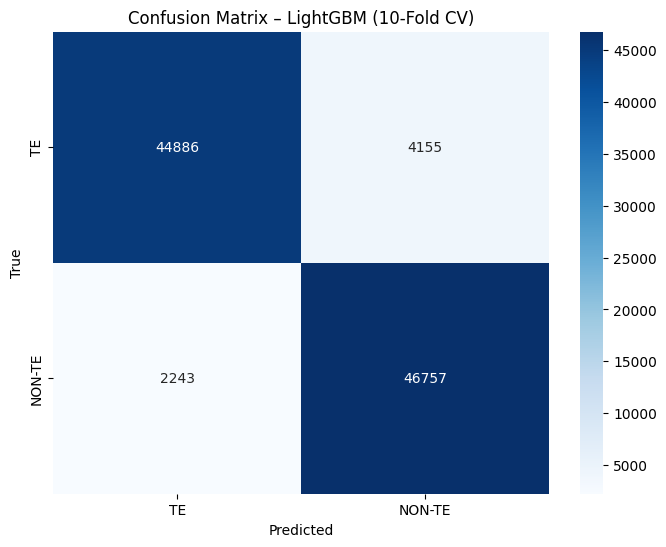

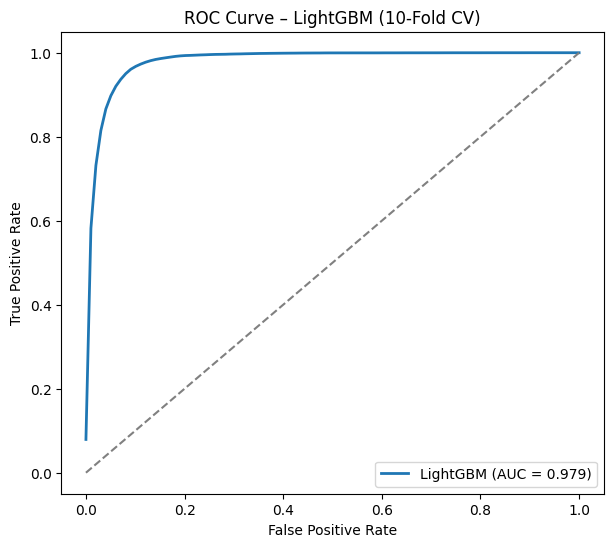

In [ ]:
# ===================== Imports =====================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    auc
)

# If lightgbm is not installed, uncomment the next line in Colab
!pip install lightgbm

from lightgbm import LGBMClassifier

# ===================== Cross-validation setup =====================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ===================== Storage (IMPORTANT for t-test & ROC) =====================
lgbm_acc_scores = []
lgbm_mcc_scores = []
lgbm_sen_scores = []
lgbm_spe_scores = []
lgbm_auc_scores = []

lgbm_fpr_list = []
lgbm_tpr_list = []

y_true_all_lgbm = []
y_pred_all_lgbm = []

# ===================== Cross-validation loop =====================
for fold, (train_idx, test_idx) in enumerate(skf.split(feature, labels), 1):
    X_train, X_test = feature[train_idx], feature[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    model_lgbm = LGBMClassifier(
        n_estimators=100
    )

    model_lgbm.fit(X_train, y_train)

    # Predictions
    y_pred_lgbm = model_lgbm.predict(X_test)
    y_prob_lgbm = model_lgbm.predict_proba(X_test)[:, 1]

    # Store global predictions
    y_true_all_lgbm.extend(y_test)
    y_pred_all_lgbm.extend(y_pred_lgbm)

    # ---------------- Metrics ----------------
    acc = accuracy_score(y_test, y_pred_lgbm)
    mcc = matthews_corrcoef(y_test, y_pred_lgbm)

    cm = confusion_matrix(y_test, y_pred_lgbm)
    TP = cm[1, 1]
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)

    fpr, tpr, _ = roc_curve(y_test, y_prob_lgbm)
    roc_auc = auc(fpr, tpr)

    # Store fold-wise results
    lgbm_acc_scores.append(acc)
    lgbm_mcc_scores.append(mcc)
    lgbm_sen_scores.append(sensitivity)
    lgbm_spe_scores.append(specificity)
    lgbm_auc_scores.append(roc_auc)

    lgbm_fpr_list.append(fpr)
    lgbm_tpr_list.append(tpr)

# ===================== Statistical Summary =====================
print("LightGBM – 10-Fold Cross-Validation (Mean ± Std)\n")
print(f"Accuracy    : {np.mean(lgbm_acc_scores):.3f} ± {np.std(lgbm_acc_scores, ddof=1):.3f}")
print(f"MCC         : {np.mean(lgbm_mcc_scores):.3f} ± {np.std(lgbm_mcc_scores, ddof=1):.3f}")
print(f"Sensitivity : {np.mean(lgbm_sen_scores):.3f} ± {np.std(lgbm_sen_scores, ddof=1):.3f}")
print(f"Specificity : {np.mean(lgbm_spe_scores):.3f} ± {np.std(lgbm_spe_scores, ddof=1):.3f}")
print(f"AUC         : {np.mean(lgbm_auc_scores):.3f} ± {np.std(lgbm_auc_scores, ddof=1):.3f}")

# ===================== Final Confusion Matrix =====================
cm_final_lgbm = confusion_matrix(y_true_all_lgbm, y_pred_all_lgbm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_final_lgbm,
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=['TE', 'NON-TE'],
    yticklabels=['TE', 'NON-TE']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – LightGBM (10-Fold CV)')
plt.savefig('lgbm_cv_confusion_matrix.png', dpi=600)
plt.show()

# ===================== ROC Curve (Mean ROC) =====================
mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)

for fpr, tpr in zip(lgbm_fpr_list, lgbm_tpr_list):
    mean_tpr += np.interp(mean_fpr, fpr, tpr)

mean_tpr /= len(lgbm_fpr_list)
mean_auc = auc(mean_fpr, mean_tpr)

plt.figure(figsize=(7, 6))
plt.plot(mean_fpr, mean_tpr,
         label=f'LightGBM (AUC = {mean_auc:.3f})',
         linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – LightGBM (10-Fold CV)')
plt.legend(loc='lower right')
plt.savefig('lgbm_cv_roc.png', dpi=600)
plt.show()


Decision Tree – 10-Fold Cross-Validation (Mean ± Std)

Accuracy    : 0.903 ± 0.004
MCC         : 0.806 ± 0.007
Sensitivity : 0.892 ± 0.004
Specificity : 0.913 ± 0.004
AUC         : 0.905 ± 0.004


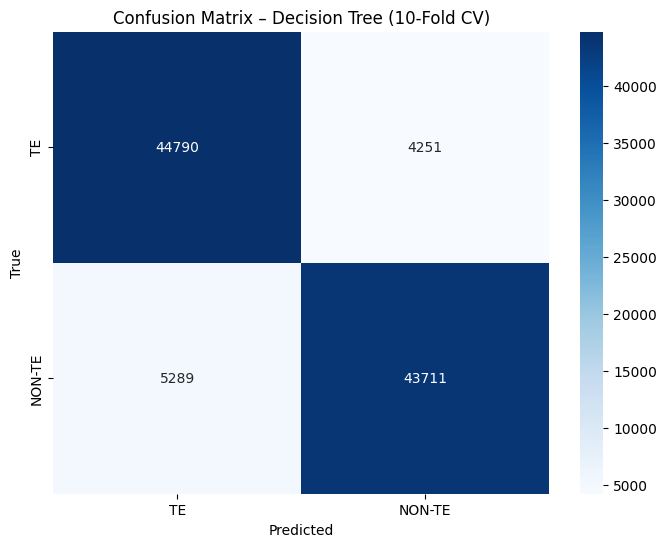

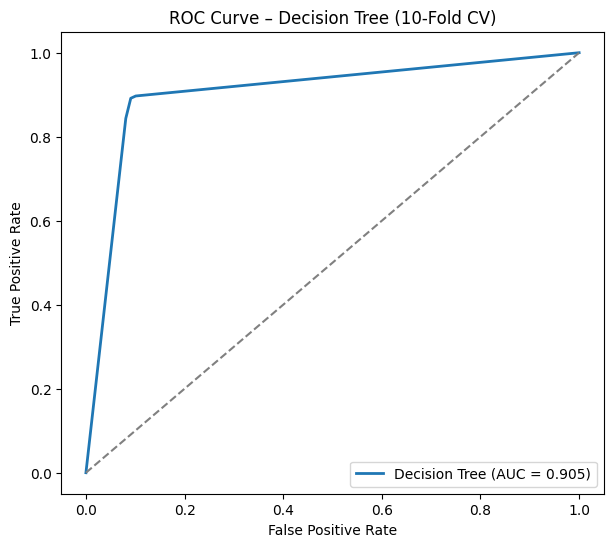

In [ ]:
# ===================== Imports =====================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.tree import DecisionTreeClassifier

# ===================== Cross-validation setup =====================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ===================== Storage (IMPORTANT for t-test & ROC) =====================
dt_acc_scores = []
dt_mcc_scores = []
dt_sen_scores = []
dt_spe_scores = []
dt_auc_scores = []

dt_fpr_list = []
dt_tpr_list = []

y_true_all_dt = []
y_pred_all_dt = []

# ===================== Cross-validation loop =====================
for fold, (train_idx, test_idx) in enumerate(skf.split(feature, labels), 1):
    X_train, X_test = feature[train_idx], feature[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    model_dt = DecisionTreeClassifier()

    model_dt.fit(X_train, y_train)

    # Predictions
    y_pred_dt = model_dt.predict(X_test)
    y_prob_dt = model_dt.predict_proba(X_test)[:, 1]

    # Store global predictions
    y_true_all_dt.extend(y_test)
    y_pred_all_dt.extend(y_pred_dt)

    # ---------------- Metrics ----------------
    acc = accuracy_score(y_test, y_pred_dt)
    mcc = matthews_corrcoef(y_test, y_pred_dt)

    cm = confusion_matrix(y_test, y_pred_dt)
    TP = cm[1, 1]
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)

    fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
    roc_auc = auc(fpr, tpr)

    # Store fold-wise results
    dt_acc_scores.append(acc)
    dt_mcc_scores.append(mcc)
    dt_sen_scores.append(sensitivity)
    dt_spe_scores.append(specificity)
    dt_auc_scores.append(roc_auc)

    dt_fpr_list.append(fpr)
    dt_tpr_list.append(tpr)

# ===================== Statistical Summary =====================
print("Decision Tree – 10-Fold Cross-Validation (Mean ± Std)\n")
print(f"Accuracy    : {np.mean(dt_acc_scores):.3f} ± {np.std(dt_acc_scores, ddof=1):.3f}")
print(f"MCC         : {np.mean(dt_mcc_scores):.3f} ± {np.std(dt_mcc_scores, ddof=1):.3f}")
print(f"Sensitivity : {np.mean(dt_sen_scores):.3f} ± {np.std(dt_sen_scores, ddof=1):.3f}")
print(f"Specificity : {np.mean(dt_spe_scores):.3f} ± {np.std(dt_spe_scores, ddof=1):.3f}")
print(f"AUC         : {np.mean(dt_auc_scores):.3f} ± {np.std(dt_auc_scores, ddof=1):.3f}")

# ===================== Final Confusion Matrix =====================
cm_final_dt = confusion_matrix(y_true_all_dt, y_pred_all_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_final_dt,
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=['TE', 'NON-TE'],
    yticklabels=['TE', 'NON-TE']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – Decision Tree (10-Fold CV)')
plt.savefig('dt_cv_confusion_matrix.png', dpi=600)
plt.show()

# ===================== ROC Curve (Mean ROC) =====================
mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)

for fpr, tpr in zip(dt_fpr_list, dt_tpr_list):
    mean_tpr += np.interp(mean_fpr, fpr, tpr)

mean_tpr /= len(dt_fpr_list)
mean_auc = auc(mean_fpr, mean_tpr)

plt.figure(figsize=(7, 6))
plt.plot(mean_fpr, mean_tpr,
         label=f'Decision Tree (AUC = {mean_auc:.3f})',
         linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Decision Tree (10-Fold CV)')
plt.legend(loc='lower right')
plt.savefig('dt_cv_roc.png', dpi=600)
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 1.5 MB/s eta 0:00:00
XGBoost – 10-Fold Cross-Validation (Mean ± Std)

Accuracy    : 0.940 ± 0.003
MCC         : 0.881 ± 0.005
Sensitivity : 0.957 ± 0.003
Specificity : 0.924 ± 0.004
AUC         : 0.983 ± 0.001


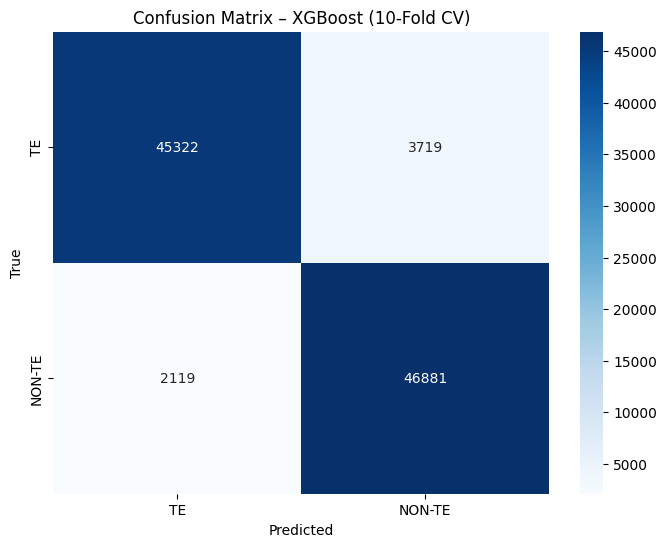

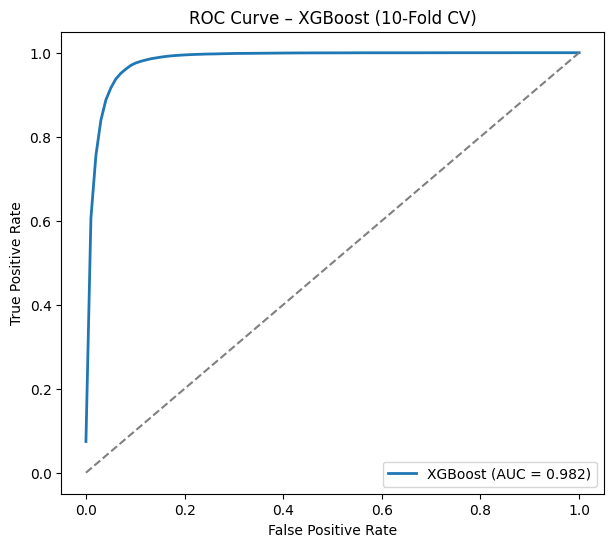

In [ ]:
# ===================== Imports =====================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    auc
)

# If xgboost is not installed, uncomment the next line
!pip install xgboost

from xgboost import XGBClassifier

# ===================== Cross-validation setup =====================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ===================== Storage (IMPORTANT for t-test & ROC) =====================
xgb_acc_scores = []
xgb_mcc_scores = []
xgb_sen_scores = []
xgb_spe_scores = []
xgb_auc_scores = []

xgb_fpr_list = []
xgb_tpr_list = []

y_true_all_xgb = []
y_pred_all_xgb = []

# ===================== Cross-validation loop =====================
for fold, (train_idx, test_idx) in enumerate(skf.split(feature, labels), 1):
    X_train, X_test = feature[train_idx], feature[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    model_xgb = XGBClassifier(
        n_estimators=100
    )

    model_xgb.fit(X_train, y_train)

    # Predictions
    y_pred_xgb = model_xgb.predict(X_test)
    y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

    # Store global predictions
    y_true_all_xgb.extend(y_test)
    y_pred_all_xgb.extend(y_pred_xgb)

    # ---------------- Metrics ----------------
    acc = accuracy_score(y_test, y_pred_xgb)
    mcc = matthews_corrcoef(y_test, y_pred_xgb)

    cm = confusion_matrix(y_test, y_pred_xgb)
    TP = cm[1, 1]
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)

    fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
    roc_auc = auc(fpr, tpr)

    # Store fold-wise results
    xgb_acc_scores.append(acc)
    xgb_mcc_scores.append(mcc)
    xgb_sen_scores.append(sensitivity)
    xgb_spe_scores.append(specificity)
    xgb_auc_scores.append(roc_auc)

    xgb_fpr_list.append(fpr)
    xgb_tpr_list.append(tpr)

# ===================== Statistical Summary =====================
print("XGBoost – 10-Fold Cross-Validation (Mean ± Std)\n")
print(f"Accuracy    : {np.mean(xgb_acc_scores):.3f} ± {np.std(xgb_acc_scores, ddof=1):.3f}")
print(f"MCC         : {np.mean(xgb_mcc_scores):.3f} ± {np.std(xgb_mcc_scores, ddof=1):.3f}")
print(f"Sensitivity : {np.mean(xgb_sen_scores):.3f} ± {np.std(xgb_sen_scores, ddof=1):.3f}")
print(f"Specificity : {np.mean(xgb_spe_scores):.3f} ± {np.std(xgb_spe_scores, ddof=1):.3f}")
print(f"AUC         : {np.mean(xgb_auc_scores):.3f} ± {np.std(xgb_auc_scores, ddof=1):.3f}")

# ===================== Final Confusion Matrix =====================
cm_final_xgb = confusion_matrix(y_true_all_xgb, y_pred_all_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_final_xgb,
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=['TE', 'NON-TE'],
    yticklabels=['TE', 'NON-TE']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – XGBoost (10-Fold CV)')
plt.savefig('xgb_cv_confusion_matrix.png', dpi=600)
plt.show()

# ===================== ROC Curve (Mean ROC) =====================
mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)

for fpr, tpr in zip(xgb_fpr_list, xgb_tpr_list):
    mean_tpr += np.interp(mean_fpr, fpr, tpr)

mean_tpr /= len(xgb_fpr_list)
mean_auc = auc(mean_fpr, mean_tpr)

plt.figure(figsize=(7, 6))
plt.plot(
    mean_fpr,
    mean_tpr,
    label=f'XGBoost (AUC = {mean_auc:.3f})',
    linewidth=2
)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – XGBoost (10-Fold CV)')
plt.legend(loc='lower right')
plt.savefig('xgb_cv_roc.png', dpi=600)
plt.show()


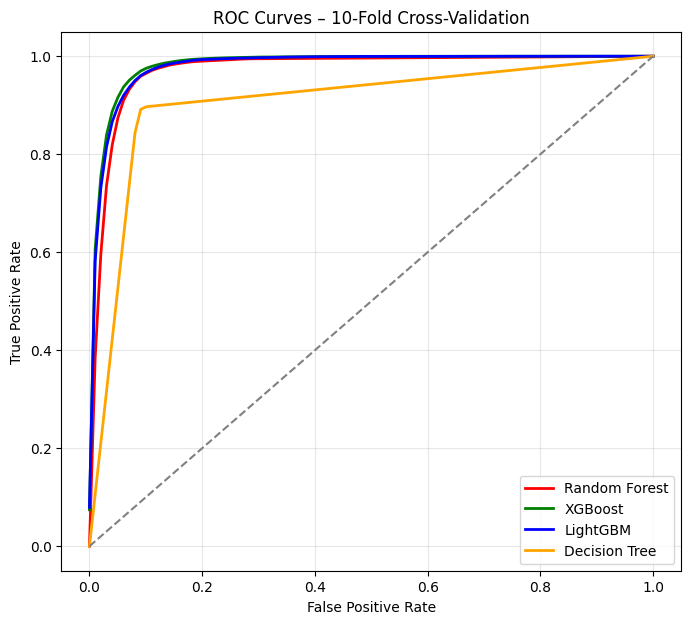

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc

# ===================== Mean ROC for Random Forest =====================
mean_fpr = np.linspace(0, 1, 100)

mean_tpr_rf = np.zeros_like(mean_fpr)
for fpr, tpr in zip(rf_fpr_list, rf_tpr_list):
    mean_tpr_rf += np.interp(mean_fpr, fpr, tpr)
mean_tpr_rf /= len(rf_fpr_list)
mean_auc_rf = auc(mean_fpr, mean_tpr_rf)

# ===================== Mean ROC for XGBoost =====================
mean_tpr_xgb = np.zeros_like(mean_fpr)
for fpr, tpr in zip(xgb_fpr_list, xgb_tpr_list):
    mean_tpr_xgb += np.interp(mean_fpr, fpr, tpr)
mean_tpr_xgb /= len(xgb_fpr_list)
mean_auc_xgb = auc(mean_fpr, mean_tpr_xgb)

# ===================== Mean ROC for LightGBM =====================
mean_tpr_lgbm = np.zeros_like(mean_fpr)
for fpr, tpr in zip(lgbm_fpr_list, lgbm_tpr_list):
    mean_tpr_lgbm += np.interp(mean_fpr, fpr, tpr)
mean_tpr_lgbm /= len(lgbm_fpr_list)
mean_auc_lgbm = auc(mean_fpr, mean_tpr_lgbm)

# ===================== Mean ROC for Decision Tree =====================
mean_tpr_dt = np.zeros_like(mean_fpr)
for fpr, tpr in zip(dt_fpr_list, dt_tpr_list):
    mean_tpr_dt += np.interp(mean_fpr, fpr, tpr)
mean_tpr_dt /= len(dt_fpr_list)
mean_auc_dt = auc(mean_fpr, mean_tpr_dt)

# ===================== Plot All ROC Curves =====================
plt.figure(figsize=(8, 7))

plt.plot(mean_fpr, mean_tpr_rf,
         color='red',
         linewidth=2,
         label='Random Forest')

plt.plot(mean_fpr, mean_tpr_xgb,
         color='green',
         linewidth=2,
         label='XGBoost')

plt.plot(mean_fpr, mean_tpr_lgbm,
         color='blue',
         linewidth=2,
         label='LightGBM')

plt.plot(mean_fpr, mean_tpr_dt,
         color='orange',
         linewidth=2,
         label='Decision Tree')

# Diagonal line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Labels & Title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – 10-Fold Cross-Validation')

plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.savefig('cross_val_combined_roc.png', dpi=600)
plt.show()


In [ ]:
import numpy as np
from scipy.stats import ttest_rel
models = {
    "XGBoost": {
        "acc": xgb_acc_scores,
        "mcc": xgb_mcc_scores,
        "auc": xgb_auc_scores
    },
    "Random Forest": {
        "acc": rf_acc_scores,
        "mcc": rf_mcc_scores,
        "auc": rf_auc_scores
    },
    "LightGBM": {
        "acc": lgbm_acc_scores,
        "mcc": lgbm_mcc_scores,
        "auc": lgbm_auc_scores
    },
    "Decision Tree": {
        "acc": dt_acc_scores,
        "mcc": dt_mcc_scores,
        "auc": dt_auc_scores
    }
}

def paired_ttest_general(model_a, model_b, metric):
    scores_a = models[model_a][metric]
    scores_b = models[model_b][metric]

    t_stat, p_value = ttest_rel(scores_a, scores_b)

    mean_a = np.mean(scores_a)
    mean_b = np.mean(scores_b)

    if p_value < 0.05:
        if mean_a > mean_b:
            winner = model_a
        else:
            winner = model_b
    else:
        winner = "Tie"

    return {
        "Model A": model_a,
        "Model B": model_b,
        "Metric": metric.upper(),
        "Mean A": mean_a,
        "Mean B": mean_b,
        "p-value": p_value,
        "Winner": winner
    }
results = []

model_names = list(models.keys())
metrics = ["acc", "mcc", "auc"]

for metric in metrics:
    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            res = paired_ttest_general(
                model_names[i],
                model_names[j],
                metric
            )
            results.append(res)
for r in results:
    print(f"\n{r['Metric']}: {r['Model A']} vs {r['Model B']}")
    print(f"Mean {r['Model A']} = {r['Mean A']:.4f}")
    print(f"Mean {r['Model B']} = {r['Mean B']:.4f}")
    print(f"p-value = {r['p-value']:.6f}")

    if r['Winner'] == "Tie":
        print("Conclusion: No statistically significant difference")
    else:
        print(f"Conclusion: {r['Winner']} is statistically stronger")



ACC: XGBoost vs Random Forest
Mean XGBoost = 0.9405
Mean Random Forest = 0.9329
p-value = 0.000002
Conclusion: XGBoost is statistically stronger

ACC: XGBoost vs LightGBM
Mean XGBoost = 0.9405
Mean LightGBM = 0.9347
p-value = 0.000000
Conclusion: XGBoost is statistically stronger

ACC: XGBoost vs Decision Tree
Mean XGBoost = 0.9405
Mean Decision Tree = 0.9027
p-value = 0.000000
Conclusion: XGBoost is statistically stronger

ACC: Random Forest vs LightGBM
Mean Random Forest = 0.9329
Mean LightGBM = 0.9347
p-value = 0.001792
Conclusion: LightGBM is statistically stronger

ACC: Random Forest vs Decision Tree
Mean Random Forest = 0.9329
Mean Decision Tree = 0.9027
p-value = 0.000000
Conclusion: Random Forest is statistically stronger

ACC: LightGBM vs Decision Tree
Mean LightGBM = 0.9347
Mean Decision Tree = 0.9027
p-value = 0.000000
Conclusion: LightGBM is statistically stronger

MCC: XGBoost vs Random Forest
Mean XGBoost = 0.8814
Mean Random Forest = 0.8660
p-value = 0.000002
Conclusion

In [ ]:
import numpy as np
from scipy.stats import ttest_rel

# ===============================
# MCC scores from 10-fold CV
# (These must already be computed)
# ===============================
models = {
    "XGBoost": xgb_mcc_scores,
    "Random Forest": rf_mcc_scores,
    "LightGBM": lgbm_mcc_scores,
    "Decision Tree": dt_mcc_scores
}

# ===============================
# Paired t-test function (MCC only)
# ===============================
def paired_ttest_mcc(model_a, model_b):
    scores_a = np.array(models[model_a])
    scores_b = np.array(models[model_b])

    t_stat, p_value = ttest_rel(scores_a, scores_b)

    mean_a = np.mean(scores_a)
    mean_b = np.mean(scores_b)

    if p_value < 0.05:
        winner = model_a if mean_a > mean_b else model_b
        conclusion = f"Statistically significant difference (p < 0.05); {winner} performs better"
    else:
        conclusion = "No statistically significant difference (p ≥ 0.05)"

    return {
        "Model A": model_a,
        "Model B": model_b,
        "Mean MCC A": mean_a,
        "Mean MCC B": mean_b,
        "t-statistic": t_stat,
        "p-value": p_value,
        "Conclusion": conclusion
    }

# ===============================
# Run t-tests: XGBoost vs others
# ===============================
results = []

reference_model = "XGBoost"

for model in models:
    if model != reference_model:
        res = paired_ttest_mcc(reference_model, model)
        results.append(res)

# ===============================
# Print Results (Paper-ready)
# ===============================
for r in results:
    print("\n----------------------------------------")
    print(f"{r['Model A']} vs {r['Model B']}")
    print(f"Mean MCC ({r['Model A']}) = {r['Mean MCC A']:.4f}")
    print(f"Mean MCC ({r['Model B']}) = {r['Mean MCC B']:.4f}")
    print(f"t-statistic = {r['t-statistic']:.4f}")
    print(f"p-value     = {r['p-value']:.6f}")
    print("Conclusion:", r["Conclusion"])



----------------------------------------
XGBoost vs Random Forest
Mean MCC (XGBoost) = 0.8814
Mean MCC (Random Forest) = 0.8660
t-statistic = 10.7373
p-value     = 0.000002
Conclusion: Statistically significant difference (p < 0.05); XGBoost performs better

----------------------------------------
XGBoost vs LightGBM
Mean MCC (XGBoost) = 0.8814
Mean MCC (LightGBM) = 0.8702
t-statistic = 12.8179
p-value     = 0.000000
Conclusion: Statistically significant difference (p < 0.05); XGBoost performs better

----------------------------------------
XGBoost vs Decision Tree
Mean MCC (XGBoost) = 0.8814
Mean MCC (Decision Tree) = 0.8056
t-statistic = 50.0736
p-value     = 0.000000
Conclusion: Statistically significant difference (p < 0.05); XGBoost performs better
